# Optimización de rutas con A* bidireccional

## 02 · Modelos aplicados

**Objetivo:** calcular y comparar dos rutas para cada par origen-destino:

1. Una ruta que minimiza el tiempo estimado de flujo libre;
2. Una ruta que minimiza el tiempo más una penalización por variabilidad.

Dijkstra verifica el costo obtenido por A* en ambos modelos. La simulación Monte Carlo se aplica después para evaluar las rutas; no selecciona el recorrido.

## 1. Configuración y datos reproducibles

Se importa el paquete `rutas_gam` y se vuelven a cargar la red y los puntos de estudio.

In [1]:
from pathlib import Path
import sys

for candidata in (Path.cwd(), *Path.cwd().parents):
    if (candidata / "rutas_gam").exists():
        RAIZ = candidata
        break
else:
    raise FileNotFoundError("Ejecute el notebook dentro del repositorio clonado.")

sys.path.insert(0, str(RAIZ))
DATOS_RAW = RAIZ / "data" / "raw"
DATOS_PROCESADOS = RAIZ / "data" / "processed"
FIGURAS = RAIZ / "figuras"
FIGURAS.mkdir(exist_ok=True)

import matplotlib.pyplot as plt
from IPython.display import display

import rutas_gam as rg

SEMILLA = 2026
LAMBDA_INICIAL = 1.0

LAMBDA_MAX = 10
PASO_LAMBDA = 0.5
LIMITE_RANGE = int(round(LAMBDA_MAX / PASO_LAMBDA)) + 1
VALORES_LAMBDA = tuple(indice * PASO_LAMBDA for indice in range(LIMITE_RANGE))

print("Configuración reproducible lista.")
print("Semilla:", SEMILLA)
print("Lambda inicial:", LAMBDA_INICIAL)

Configuración reproducible lista.
Semilla: 2026
Lambda inicial: 1.0


## 2. Preparación de los pares de estudio

Los tres pares se fijaron manualmente con paradas reales de OSM ubicadas en lados opuestos de Circunvalación:

* `Estadio Oeste–San Pedro` -> oeste a este.
* `Cuatro Reinas–Paso Ancho` -> norte a sur.
* `Hatillo–Curridabat` -> suroeste a este.

Los seis extremos se guardan en `puntos_estudio.csv` para que su ubicación sea reproducible. En esta sección se preparan los nodos de origen, destino y referencia intermedia; las rutas se calculan posteriormente al ejecutar los modelos y construir la referencia base.

### Preparación de la red y de los puntos

Primero se carga la red vial dirigida y se calculan los tiempos estimados de sus arcos. Después se cargan los seis puntos de estudio y las 20 paradas ordenadas por importancia. Cada punto se conecta al nodo vial más cercano para que pueda utilizarse dentro del grafo.

Los puntos de estudio se mantienen separados de las paradas importantes: el índice $w_i$ responde a densidad y destinos cercanos, mientras la elección de los pares responde a cobertura geográfica.

In [2]:
datos = rg.cargar_datos_estudio(
    DATOS_RAW / "red_san_jose.graphml",
    DATOS_PROCESADOS / "paradas_importantes.csv",
    DATOS_PROCESADOS / "puntos_estudio.csv",
)
display(rg.tabla_puntos_visual(datos.puntos_estudio))

,Nombre,Sector
0,Estadio Oeste,Oeste
1,San Pedro - Carmiol,Este
2,Terminal Cuatro Reinas,Norte
3,Parada El Caracol,Sur
4,Periférica Hatillo,Suroeste
5,Plaza del Sol,Este


### Definición reproducible de los pares

Las paradas importantes y los puntos de estudio se reúnen en `puntos_busqueda`. La función `buscar_parada` permite localizar cada punto a partir de una parte de su nombre.

Cada configuración contiene el nombre del par, el origen, el destino y un punto intermedio. Los extremos proceden de `puntos_estudio.csv` y el punto intermedio se toma de las paradas importantes. Con estos tres puntos se construye una **ruta base reproducible** que minimiza la distancia entre el origen, el punto intermedio y el destino.

In [3]:
configuraciones = [
    ("Estadio Oeste → San Pedro", "Estadio Oeste", "San Pedro - Carmiol", "Torre Mercedes"),
    ("Cuatro Reinas → Paso Ancho", "Terminal Cuatro Reinas", "Parada El Caracol", "Hospital de Niños"),
    ("Hatillo → Curridabat", "Periférica Hatillo", "Plaza del Sol", "Paseo Colon"),
]

### Nodos preparados para los modelos

Finalmente, los nombres de cada configuración se convierten en nodos del grafo. La lista `casos` contiene el nombre del par, el origen y el destino que serán utilizados por ambos modelos. Los puntos intermedios se guardan por separado para construir las rutas base.

La tabla presenta los tres casos preparados para el análisis.

In [4]:
casos, intermedios = rg.preparar_casos_estudio(
    datos.paradas, datos.puntos_estudio, configuraciones
)
print("Pares preparados:", len(casos))
display(rg.tabla_casos_estudio(casos))

Pares preparados: 3


,nombre,origen,destino
0,Estadio Oeste → San Pedro,179570277,288562143
1,Cuatro Reinas → Paso Ancho,277243108,3932298493
2,Hatillo → Curridabat,274952825,3107647190


## 3. Modelos utilizados

Se utilizan dos modelos para encontrar una ruta entre un origen y un destino, pero cada uno responde a un objetivo diferente:
* El **Modelo 1** minimiza el tiempo estimado de viaje en condiciones de flujo libre.
* El **Modelo 2** minimiza el tiempo estimado más una penalización por la variabilidad asociada con cada clase vial.

Ambos modelos utilizan A* bidireccional, un algoritmo que explora la red simultáneamente desde el origen y el destino hasta encontrar la ruta óptima según la función de costo correspondiente.

### A* bidireccional

A* decide qué nodo explorar usando $f(n)=g(n)+h(n)$. El término $g(n)$ representa el tiempo acumulado desde el inicio, mientras que $h(n)$ es la heurística que estima el tiempo que falta para llegar al destino. En este proyecto se define como:

$$h(n)=\frac{\operatorname{dist}_{geo}(n,D)}{v_{max}}\times 0.06$$

La distancia geodésica ($\operatorname{dist}_{geo}$) representa la separación en línea recta sobre la superficie terrestre, mientras que $v_{\max}$ corresponde a la mayor velocidad asignada en toda la red. Al combinar ambas variables se estima el menor tiempo posible de recorrido, y el factor $0.06$ convierte la relación entre metros y kilómetros por hora a minutos. Como incluso en el mejor de los casos no es posible llegar al destino en menos tiempo que esta estimación, la heurística es admisible y garantiza que no se descarte la ruta óptima.

Esta misma lógica se aplica simultáneamente desde ambos extremos del recorrido, por lo que se realizan dos búsquedas:

* Una avanza desde el origen.
* La otra avanza desde el destino utilizando el grafo inverso.

Cuando ambas fronteras encuentran una conexión y sus mejores alternativas pendientes ya no pueden mejorarla, el algoritmo se detiene y reconstruye el camino óptimo.

### Algoritmo de control

Ahora bien, para verificar que esta estrategia encuentra efectivamente la ruta óptima, se utiliza `Dijkstra` como algoritmo de control. Dijkstra emplea los mismos tiempos de arco, pero no utiliza una heurística que guíe la búsqueda, por lo que generalmente debe explorar una mayor cantidad de nodos. Esto lo hace más lento, pero también lo convierte en una referencia adecuada para validar el resultado de A*. Si ambos algoritmos funcionan correctamente, deben devolver el mismo costo óptimo.



### Cómo leer los resultados de cada modelo

| Campo | Descripción |
|---|---|
| **Par** | Nombre del recorrido entre el origen y el destino. |
| **Modelo** | Función de costo utilizada para seleccionar la ruta. |
| **Distancia (km)** | Longitud total de la ruta seleccionada. |
| **Tiempo determinista (min)** | Tiempo estimado de flujo libre, calculado a partir de las longitudes y velocidades de los arcos. |
| **Costo objetivo (min)** | Valor que el modelo busca minimizar. En el Modelo 1 corresponde al tiempo; en el Modelo 2 incluye la penalización por variabilidad. |
| **Costo A\* (min)** | Costo mínimo obtenido mediante A\* bidireccional. |
| **Costo Dijkstra (min)** | Costo mínimo obtenido mediante Dijkstra para verificar el resultado. |
| **Coincide** | Indica si A\* y Dijkstra obtuvieron el mismo costo mínimo. |
| **NE A\*** | Cantidad de nodos explorados por A\* bidireccional. |
| **NE Dijkstra** | Cantidad de nodos explorados por Dijkstra. |


### 3.1 Modelo 1: camino de menor tiempo

El primer modelo busca la ruta con el menor tiempo estimado de viaje en condiciones de flujo libre. Para ello, asigna a cada arco $(i,j)$ un costo $t_{ij}$, calculado a partir de su longitud y velocidad, y minimiza la suma de estos tiempos:

$$
R_1^*=\arg\min_{R\in P_{OD}}\sum_{(i,j)\in R}t_{ij}.
$$

En esta formulación, $P_{OD}$ representa el conjunto de rutas posibles entre el origen y el destino, y $R_1^*$ es la ruta óptima seleccionada. A* bidireccional resuelve este problema y Dijkstra permite verificar que el costo obtenido corresponde al mínimo bajo los pesos definidos.

In [5]:
resultado_modelo_1 = rg.ejecutar_modelo_menor_tiempo(
    datos.grafo, casos
)
tabla_modelo_1 = resultado_modelo_1.tabla
display(rg.tabla_modelo_visual(tabla_modelo_1))

,Par,Modelo,Distancia (km),Tiempo determinista (min),Costo objetivo (min),Costo A* (min),Costo Dijkstra (min),Coincide,NE A*,NE Dijkstra
0,Estadio Oeste → San Pedro,Menor tiempo,9.81,9.96,9.96,9.96,9.96,True,4235,4877
1,Cuatro Reinas → Paso Ancho,Menor tiempo,5.56,8.22,8.22,8.22,8.22,True,3094,3245
2,Hatillo → Curridabat,Menor tiempo,9.19,8.98,8.98,8.98,8.98,True,3197,4105


### 3.2 Modelo 2: camino ajustado por variabilidad

El segundo modelo busca una ruta que combine el tiempo estimado de viaje con la variabilidad asociada con cada clase vial. Bajo el supuesto de un multiplicador lognormal con dispersión $\sigma_{vía}$, la desviación estándar estimada del tiempo de un arco es:

$$
s_{ij}=t_{ij}\sqrt{e^{\sigma_{vía}^2}-1}.
$$

A partir de esta variabilidad, se asigna a cada arco $(i,j)$ el costo ajustado:

$$
c_{ij}^{(2)}=t_{ij}+\lambda s_{ij},
$$

y se selecciona la ruta que minimiza la suma de estos costos:

$$
R_2^*=\arg\min_{R\in P_{OD}}\sum_{(i,j)\in R}c_{ij}^{(2)}.
$$

En esta formulación, $P_{OD}$ representa el conjunto de rutas posibles entre el origen y el destino, y $R_2^*$ es la ruta óptima ajustada por variabilidad. El parámetro $\lambda$ determina cuánta importancia recibe la variabilidad: con $\lambda=0$ el modelo reproduce el camino de menor tiempo y, al aumentarlo, favorece rutas más conservadoras.

A* bidireccional resuelve el problema y Dijkstra permite verificar el costo mínimo bajo esta función objetivo. La penalización representa la variabilidad supuesta y no corresponde a un cuantil exacto ni a mediciones de tráfico observado.

Como punto de partida, el modelo se ejecuta con $\lambda=1$, de modo que el costo de cada arco corresponde a su tiempo estimado más una desviación estándar. Estos resultados iniciales se utilizan antes de comparar otros valores de $\lambda$.


In [6]:
ejecucion_modelo_2_inicial = rg.ejecutar_modelo_ajustado(
    datos.grafo, casos, LAMBDA_INICIAL
)
resultado_modelo_2_inicial = ejecucion_modelo_2_inicial.resultado
tabla_modelo_2_inicial = resultado_modelo_2_inicial.tabla
display(rg.tabla_modelo_visual(tabla_modelo_2_inicial))

,Par,Modelo,Distancia (km),Tiempo determinista (min),Costo objetivo (min),Costo A* (min),Costo Dijkstra (min),Coincide,NE A*,NE Dijkstra
0,Estadio Oeste → San Pedro,Ajustada por variabilidad,9.81,9.96,11.27,11.27,11.27,True,4587,4777
1,Cuatro Reinas → Paso Ancho,Ajustada por variabilidad,5.56,8.22,9.96,9.96,9.96,True,3824,3555
2,Hatillo → Curridabat,Ajustada por variabilidad,9.19,8.98,10.16,10.16,10.16,True,3472,3959


## 4. Selección del valor de $\lambda$

A continuación se comparan otros valores de $\lambda$ para el Modelo 2 mediante resultados deterministas. Para cada valor se calculan la distancia, el tiempo y el costo objetivo promedio de los tres pares. También se registra cuántas rutas cambian con respecto al Modelo 1.

Se prueban valores desde $\lambda=0$ hasta $\lambda=10$ con incrementos de $0.5$. Los primeros valores representan penalizaciones moderadas, mientras que los últimos permiten identificar el punto en que la variabilidad comienza a modificar la decisión. El criterio utilizado consiste en seleccionar el menor valor positivo evaluado que produzca al menos una ruta diferente. Así se evita aumentar la penalización más de lo necesario para estudiar un comportamiento distinto en ambos modelos.

El costo objetivo aumenta con $\lambda$ por definición, por lo que no se interpreta como una mejora directa entre filas. La selección se basa en el cambio de ruta y el tiempo determinista resultante. Este procedimiento corresponde a una decisión metodológica exploratoria, no a una calibración basada en tráfico observado, la cual se reserva para una etapa posterior de la investigación.

In [7]:
tabla_lambda = rg.comparar_lambda_determinista(
    datos.grafo, casos, valores=VALORES_LAMBDA
)
assert tabla_lambda["coincide_algoritmos"].all()
LAMBDA_RIESGO = rg.seleccionar_lambda_con_cambio(tabla_lambda)

display(rg.tabla_lambda_visual(tabla_lambda))
print(
    f"Se selecciona lambda = {LAMBDA_RIESGO:g}: es el menor valor "
    "probado que modifica al menos una de las tres rutas."
)

,Lambda,Distancia promedio (km),Tiempo promedio (min),Costo objetivo promedio (min),Penalización promedio (min),Rutas diferentes,Rutas diferentes (%)
0,0.0,8.19,9.05,9.05,0.00,0,0.00
1,0.5,8.19,9.05,9.76,0.71,0,0.00
2,1.0,8.19,9.05,10.47,1.41,0,0.00
3,1.5,8.19,9.05,11.17,2.12,0,0.00
4,2.0,8.19,9.05,11.88,2.83,0,0.00
5,2.5,8.19,9.05,12.58,3.53,0,0.00
6,3.0,8.19,9.05,13.29,4.24,0,0.00
7,3.5,8.19,9.05,14.00,4.94,0,0.00
8,4.0,8.19,9.05,14.70,5.65,0,0.00
9,4.5,8.19,9.05,15.41,6.36,0,0.00


Se selecciona lambda = 6.5: es el menor valor probado que modifica al menos una de las tres rutas.


### 4.1 Criterio de selección

* Los valores entre $\lambda=0$ y $\lambda=6$ conservan las tres rutas del Modelo 1. 
* Con $\lambda=6.5$ cambia uno de los tres recorridos y el tiempo determinista promedio apenas pasa de $9.05$ a $9.06$ minutos. 
* Desde $\lambda=9.5$ cambian dos rutas y el promedio aumenta a $9.84$ minutos.

Por esta razón se selecciona $\lambda=6.5$: es el menor valor probado que permite observar una decisión diferente antes del segundo cambio de ruta, que aparece desde $\lambda=9.5$.

La elección es exploratoria y depende de los supuestos de variabilidad utilizados. Con el valor seleccionado se vuelve a ejecutar el Modelo 2 para obtener las rutas que pasarán a la evaluación Monte Carlo.

In [8]:
ejecucion_modelo_2 = rg.ejecutar_modelo_ajustado(
    datos.grafo, casos, LAMBDA_RIESGO
)
grafo_ajustado = ejecucion_modelo_2.grafo
resultado_modelo_2 = ejecucion_modelo_2.resultado
tabla_modelo_2 = resultado_modelo_2.tabla

display(rg.tabla_modelo_visual(tabla_modelo_2))

print(f"Modelo 2 preparado para la simulación con lambda = {LAMBDA_RIESGO:g}.")

,Par,Modelo,Distancia (km),Tiempo determinista (min),Costo objetivo (min),Costo A* (min),Costo Dijkstra (min),Coincide,NE A*,NE Dijkstra
0,Estadio Oeste → San Pedro,Ajustada por variabilidad,9.80,9.98,18.52,18.52,18.52,True,5293,4554
1,Cuatro Reinas → Paso Ancho,Ajustada por variabilidad,5.56,8.22,19.51,19.51,19.51,True,5382,4773
2,Hatillo → Curridabat,Ajustada por variabilidad,9.19,8.98,16.67,16.67,16.67,True,4324,3640


Modelo 2 preparado para la simulación con lambda = 6.5.


## 5. Evaluación mediante simulación Monte Carlo

Una vez seleccionadas y verificadas las rutas, sus secuencias de arcos se mantienen fijas y se evalúan mediante $1.000$ réplicas. La simulación estima cómo podrían variar sus tiempos bajo los supuestos definidos para esta etapa inicial de la investigación.

### 5.1 Factores de los escenarios

En cada escenario $s$, el tiempo total de una ruta $R$ se calcula como:

$$T_R^{(s)}=G^{(s)}\sum_{(i,j)\in R}t_{ij}M_{ij}^{(s)}.$$

Donde:
* El multiplicador $M_{ij}^{(s)}$ representa la variación propia de cada arco y utiliza una dispersión $\sigma_{vía}$ según su clase vial. 
* El factor $G^{(s)}$ afecta por igual todos los arcos de la ruta y representa condiciones compartidas, como lluvia o un mayor volumen de tránsito; para este factor se utiliza $\sigma_G=0.15$. 

Ambos multiplicadores siguen distribuciones lognormales con esperanza igual a uno.

La misma semilla se utiliza para evaluar las rutas de un mismo par bajo condiciones reproducibles. Estos factores son supuestos de simulación y no mediciones de tráfico observado.

### 5.2 Métricas de evaluación

Los escenarios se resumen mediante la media, la desviación estándar, el percentil 90 y el índice de confiabilidad. Estas métricas describen la estabilidad de las rutas bajo los escenarios supuestos, no su fiabilidad empírica en condiciones reales.

El Modelo 2 utiliza la variabilidad para seleccionar su ruta, posteriormente Monte Carlo se aplica tanto al Modelo 1 como al Modelo 2 para evaluarlos con el mismo procedimiento.

In [9]:
comparacion = rg.comparar_y_simular_modelos(
    grafo_ajustado,
    [resultado_modelo_1, resultado_modelo_2],
    repeticiones=1000,
    semilla=SEMILLA,
)
tabla_determinista = comparacion.tabla_determinista
rutas_modelos = comparacion.rutas
evaluacion_monte_carlo = comparacion.evaluacion
tabla_simulacion = evaluacion_monte_carlo.tabla
simulaciones_modelos = evaluacion_monte_carlo.escenarios
display(rg.tabla_simulacion_visual(tabla_simulacion))
print("Escenarios evaluados por recorrido:", 1000)

,Par,Modelo,Tiempo determinista (min),Media simulada (min),Desviación simulada (min),Percentil 90 (min),IC %
0,Estadio Oeste → San Pedro,Menor tiempo,9.96,10.00,1.59,12.06,83.8
1,Estadio Oeste → San Pedro,Ajustada por variabilidad,9.98,10.03,1.59,12.07,83.9
2,Cuatro Reinas → Paso Ancho,Menor tiempo,8.22,8.26,1.34,10.04,82.9
3,Cuatro Reinas → Paso Ancho,Ajustada por variabilidad,8.22,8.26,1.34,10.04,82.9
4,Hatillo → Curridabat,Menor tiempo,8.98,8.93,1.37,10.75,84.4
5,Hatillo → Curridabat,Ajustada por variabilidad,8.98,8.93,1.37,10.75,84.4


Escenarios evaluados por recorrido: 1000


### 5.3 Rutas base de referencia

Para los tres pares estudiados no se dispone de recorridos oficiales de autobús. Por ello, se construye una ruta base reproducible que aproxima un recorrido existente al obligarlo a pasar por una parada intermedia. Estas rutas son referencias metodológicas y no representan itinerarios oficiales ni observaciones reales.

Para cada par se calcula primero el camino de menor distancia entre el origen y el punto intermedio, y después entre el punto intermedio y el destino. Ambos segmentos se unen para formar la ruta base:

$$R_{base}=R_{O,I}^{distancia}\oplus R_{I,D}^{distancia}.$$

Los recorridos utilizados como referencia son:

* Estadio Oeste → Torre Mercedes → San Pedro - Carmiol.
* Terminal Cuatro Reinas → Hospital de Niños - Paseo Colón → Parada El Caracol.
* Periférica Hatillo → Paseo Colón → Plaza del Sol.

Las rutas base se calculan nuevamente y se evalúan con el mismo diseño Monte Carlo. Sus medias se incorporan a la tabla resumen y sus réplicas al histograma como referencia visual.

,Modelo 1 (min),Modelo 2 (min),Ruta base (min),Mejora Modelo 1 (%),Mejora Modelo 2 (%)
Par,,,,,
Estadio Oeste → San Pedro,10.00,10.03,11.14,10.23,9.98
Cuatro Reinas → Paso Ancho,8.26,8.26,8.62,4.24,4.24
Hatillo → Curridabat,8.93,8.93,12.40,27.92,27.92
Promedio,9.06,9.07,10.72,14.13,14.05


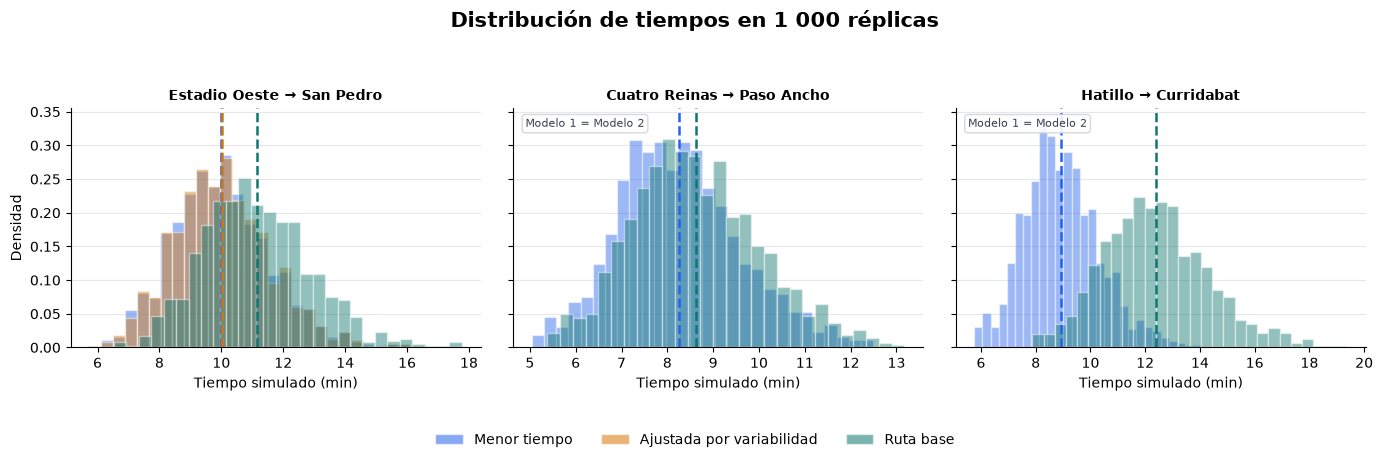

In [10]:
referencias = rg.construir_y_simular_rutas_base(
    datos.grafo,
    grafo_ajustado,
    casos,
    intermedios,
    simulaciones_modelos,
    repeticiones=1000,
    semilla=SEMILLA,
)
rutas_base = referencias.rutas
evaluacion_ruta_base = referencias.evaluacion
tabla_rutas_base = evaluacion_ruta_base.tabla
simulaciones = referencias.escenarios

tabla_resumen_histograma = rg.resumir_comparacion_con_ruta_base(
    tabla_simulacion,
    tabla_rutas_base,
    modelos=[resultado_modelo_1.modelo.nombre, resultado_modelo_2.modelo.nombre],
)
display(tabla_resumen_histograma.round(2))

rg.graficar_simulaciones(
    simulaciones, FIGURAS / "05_simulacion_modelos.png"
)
plt.show()

**Lectura de la tabla y los histogramas:** 

La tabla presenta la media simulada de cada recorrido. Una mejora positiva indica que el modelo obtuvo un tiempo medio menor que la ruta base.

En los histogramas, una distribución más a la izquierda representa menores tiempos y una distribución más estrecha indica menor variabilidad. Las líneas discontinuas señalan las medias simuladas. 

Cuando los dos modelos producen la misma distribución, se muestran como una sola serie para evitar que un color oculte al otro. La ruta base aparece como referencia separada.

**Resultados:**
En el par *Estadio Oeste → San Pedro*, el valor seleccionado de $\lambda$ produce una ruta diferente y una distribución simulada ligeramente distinta. En los otros dos pares, ambos modelos conservan la misma ruta y sus distribuciones coinciden. Frente a las rutas base, la mejora media es de $14.13\%$ para el Modelo 1 y de $14.05\%$ para el Modelo 2.

## 6. Comparación de los resultados

Los resultados de ambos modelos se comparan para los mismos tres pares origen–destino mediante el mismo diseño de simulación. La comparación considera las rutas seleccionadas, sus tiempos deterministas y las métricas obtenidas mediante Monte Carlo, con el propósito de determinar si la penalización por variabilidad modifica el recorrido elegido y mejora su comportamiento bajo los supuestos evaluados.

### 6.1 Comparación con la ruta base

La reducción de tiempo $RT$ compara el tiempo determinista del **Modelo 1** con el de la ruta base. La reducción de variabilidad $RV$ compara sus desviaciones bajo el mismo diseño Monte Carlo.

In [11]:
resultados_rutas = rg.resumir_resultados_referencia(
    casos, intermedios, tabla_modelo_1, tabla_simulacion,
    tabla_rutas_base, resultado_modelo_1.modelo.nombre,
)
display(rg.tabla_referencia_visual(resultados_rutas))
rg.validar_tiempos_esperados(resultados_rutas, [9.96, 8.22, 8.98])

,Par,Tiempo óptimo (min),Tiempo base (min),RT %,RV %,IC %,NE,NE Dijkstra
0,Estadio Oeste → San Pedro,9.96,11.11,10.35,9.12,83.8,4235,4877
1,Cuatro Reinas → Paso Ancho,8.22,8.59,4.32,3.86,82.9,3094,3245
2,Hatillo → Curridabat,8.98,12.45,27.86,27.82,84.4,3197,4105


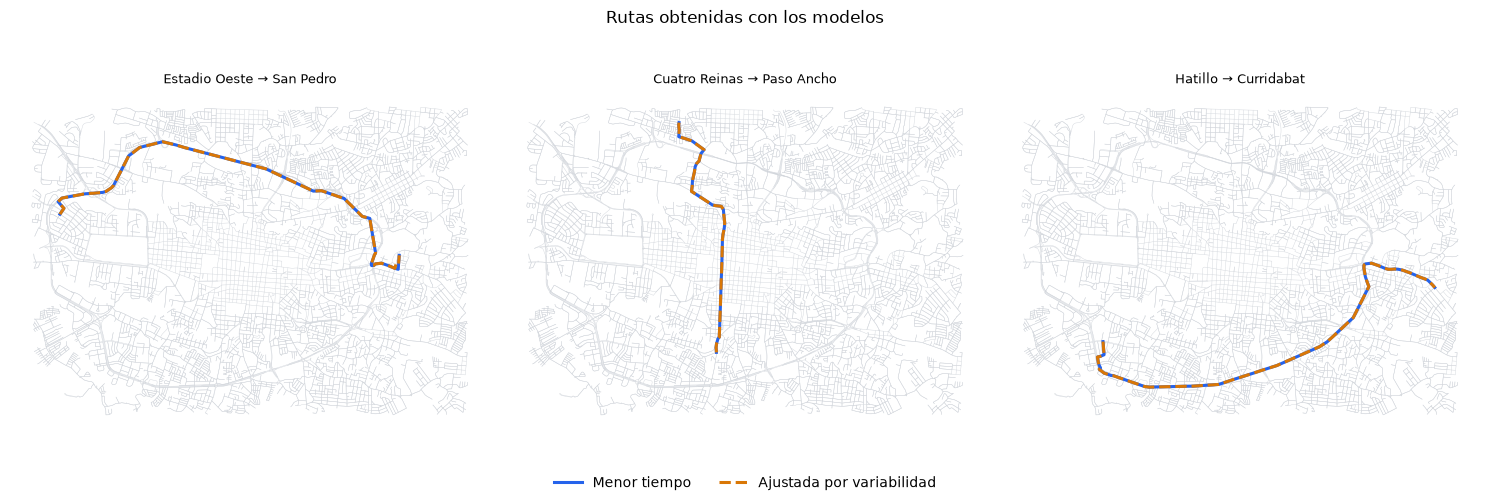

In [12]:
rg.graficar_rutas_modelos(
    grafo_ajustado, rutas_modelos, FIGURAS / "04_rutas_modelos.png"
)
plt.show()

**Lectura de mapas:** la línea azul corresponde al modelo de menor tiempo y la línea naranja discontinua el modelo de camino ajustado por variabilidad.

**Resultados:** en el par *Estadio Oeste → San Pedro*, las líneas siguen recorridos diferentes porque la penalización con $\lambda=6.5$ modifica la ruta seleccionada. Mientras que en los pares de *Cuatro Reinas → Paso Ancho* y *Hatillo → Curridabat*, las líneas se superponen porque ambos criterios conservan la misma secuencia de arcos.

### 6.2 Comparación cuantitativa de los modelos

La comparación reúne la selección determinista y la evaluación Monte Carlo. El Modelo 1 funciona como referencia para identificar si la penalización por variabilidad $\lambda$ modifica la secuencia de arcos elegida.

La columna **Ruta diferente** indica si el segundo modelo seleccionó un recorrido distinto. Una coincidencia completa también es un resultado válido: significa que la ruta de menor tiempo se mantiene al incorporar la penalización por variabilidad.

,Par,Modelo,Tiempo determinista (min),Media simulada (min),Desviación simulada (min),Percentil 90 (min),IC %,Ruta diferente
0,Estadio Oeste → San Pedro,Menor tiempo,9.96,10.00,1.59,12.06,83.8,True
1,Cuatro Reinas → Paso Ancho,Menor tiempo,8.22,8.26,1.34,10.04,82.9,False
2,Hatillo → Curridabat,Menor tiempo,8.98,8.93,1.37,10.75,84.4,False
3,Estadio Oeste → San Pedro,Ajustada por variabilidad,9.98,10.03,1.59,12.07,83.9,True
4,Cuatro Reinas → Paso Ancho,Ajustada por variabilidad,8.22,8.26,1.34,10.04,82.9,False
5,Hatillo → Curridabat,Ajustada por variabilidad,8.98,8.93,1.37,10.75,84.4,False


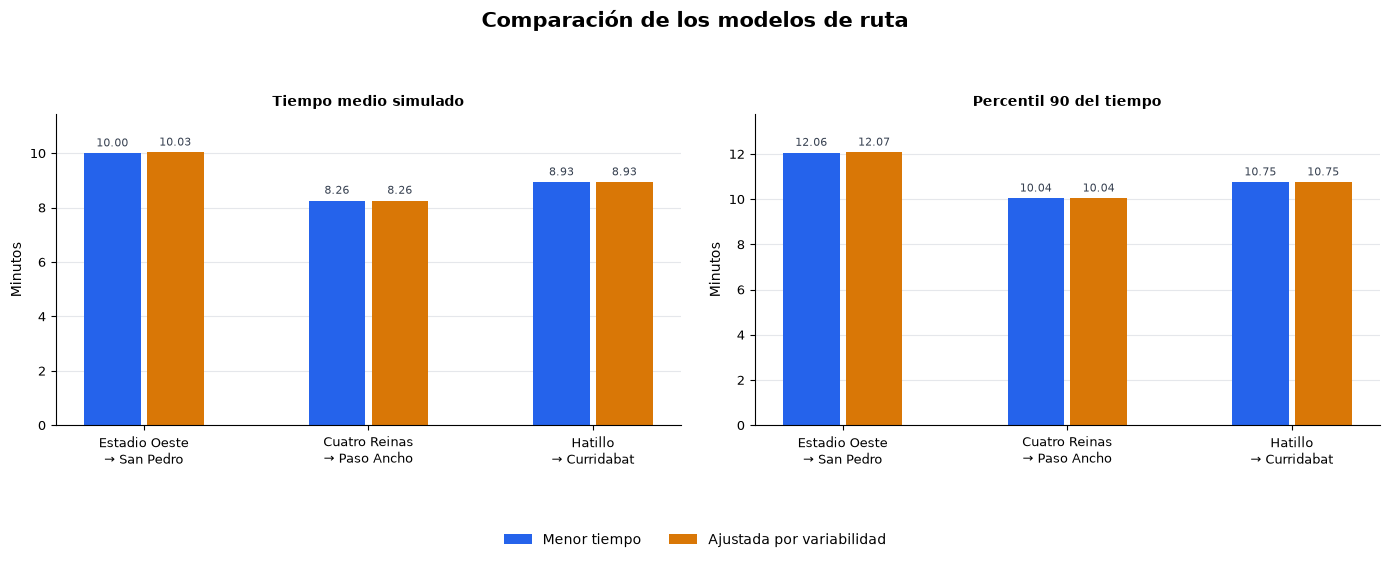

,par,ruta_cambio
0,Estadio Oeste → San Pedro,True
1,Cuatro Reinas → Paso Ancho,False
2,Hatillo → Curridabat,False


Rutas diferentes con lambda = 6.5: 1 de 3


In [13]:
tabla_modelos = rg.incorporar_metricas_simuladas(
    tabla_determinista, evaluacion_monte_carlo
)
display(rg.tabla_comparacion_visual(tabla_modelos))

rg.graficar_comparacion_modelos(
    tabla_modelos, FIGURAS / "06_comparacion_modelos.png"
)
plt.show()

resumen_cambios = rg.resumir_cambios_modelos(tabla_modelos)
display(resumen_cambios)
print(f"Rutas diferentes con lambda = {LAMBDA_RIESGO:g}:",
      int(resumen_cambios["ruta_cambio"].sum()),
      "de", len(resumen_cambios))

**Resultados:** con $\lambda=6.5$, el Modelo 2 selecciona una ruta diferente para el par *Estadio Oeste → San Pedro* y conserva las rutas del Modelo 1 en los otros dos pares. El cambio aumenta la media simulada de ese recorrido de $10.00$ a $10.03$ minutos y mantiene prácticamente iguales su desviación y percentil 90.

El Modelo 1 conserva el menor tiempo medio en estos casos mientras que el Modelo 2 permite estudiar cómo una penalización más fuerte puede modificar la decisión, aunque la simulación no muestra una mejora relevante para la ruta que cambia.

## 7. Resultados que pasan a validación

Los resultados exportados se utilizarán para verificar ambos modelos sobre 30 pares adicionales y analizar su sensibilidad ante $\lambda$, las velocidades imputadas y el número de réplicas.

In [14]:
resultados_rutas.to_csv(DATOS_PROCESADOS / "resultados_rutas.csv", index=False)
tabla_modelos.to_csv(DATOS_PROCESADOS / "comparacion_modelos.csv", index=False)
print("Guardados resultados_rutas.csv y comparacion_modelos.csv")

Guardados resultados_rutas.csv y comparacion_modelos.csv
